# Assignment 3 · Parte 2 · Mapas

**¿La lluvia y las declaratorias de emergencia se reparten igual en el
territorio?**

Grupo 9 · Diplomado PUCP 2026

In [1]:
import pandas as pd
import geopandas as gpd
import folium

## 1. Cargar la tabla y el mapa

La tabla ya trae `ubigeo` de 2 dígitos. El mapa departamental **no trae
ubigeo**: solo el nombre del departamento en mayúsculas y sin tildes.
Hay que construir el ubigeo del mapa antes de cruzar.

In [2]:
datos = pd.read_csv("datos/dataset.csv", dtype={"ubigeo": str})
datos[["ubigeo", "departamento", "lluvia_total_mm"]].head(3)

,ubigeo,departamento,lluvia_total_mm
0,01,Amazonas,436.5
1,02,Áncash,975.3
2,03,Apurímac,711.8


In [3]:
mapa = gpd.read_file("datos/departamentos_peru.geojson")
print("Departamentos en el mapa:", len(mapa))
mapa.head(3)

Departamentos en el mapa: 25


,departamento,geometry
0,AMAZONAS,"POLYGON ((-78.03025 -6.7661, -78.04983 -6.6838..."
1,ANCASH,"POLYGON ((-77.69239 -10.3209, -77.75251 -10.32..."
2,APURIMAC,"POLYGON ((-73.51174 -14.53852, -73.52075 -14.5..."


## 2. Ponerle ubigeo al mapa

`ubigeos.csv` es la libreta de códigos: ubigeo y nombre con tildes
(`Áncash`). Para pegarla con el mapa (`ANCASH`) igualamos los dos nombres:
sin tildes y en mayúsculas.

In [4]:
libreta = pd.read_csv("datos/ubigeos.csv", dtype={"ubigeo": str})

# NFKD separa la tilde de la letra; encode/decode "ascii" descarta la tilde.
nombre = libreta["departamento"].str.normalize("NFKD")
nombre = nombre.str.encode("ascii", errors="ignore").str.decode("ascii")
libreta["llave"] = nombre.str.upper()

libreta.head(3)

,ubigeo,departamento,llave
0,01,Amazonas,AMAZONAS
1,02,Áncash,ANCASH
2,03,Apurímac,APURIMAC


In [5]:
mapa["llave"] = mapa["departamento"].str.upper()
mapa = mapa.drop(columns="departamento")

mapa = mapa.merge(libreta, on="llave", how="left")
print("Departamentos del mapa sin ubigeo:", mapa["ubigeo"].isna().sum())
mapa[["ubigeo", "departamento"]].head(3)

Departamentos del mapa sin ubigeo: 0


,ubigeo,departamento
0,01,Amazonas
1,02,Áncash
2,03,Apurímac


## 3. El error más común: ubigeo leído como número

Mostramos qué pasa si se lee sin `dtype=str`. Es lo que rompe más mapas
en este curso.

In [6]:
mal_leido = pd.read_csv("datos/dataset.csv")
print("Tipo del ubigeo mal leído:", mal_leido["ubigeo"].dtype)
print("Primeros valores:", mal_leido["ubigeo"].head(3).tolist())
print("Coinciden con el mapa:", len(set(mal_leido["ubigeo"].astype(str)) & set(mapa["ubigeo"])))

Tipo del ubigeo mal leído: int64
Primeros valores: [1, 2, 3]
Coinciden con el mapa: 16


Con `dtype=str` (como lo cargamos arriba) el cruce funciona.

## 4. Cruzar y reportar lo que no cruzó

Cruzamos **desde el mapa** (`how="left"`) para no perder departamentos, y
`indicator=True` nos dice de dónde vino cada fila.

In [7]:
mapa_con_datos = mapa.merge(
    datos.drop(columns="departamento"), on="ubigeo", how="left", indicator=True
)
mapa_con_datos["_merge"].value_counts()

_merge
both          25
left_only      0
right_only     0
Name: count, dtype: int64

In [8]:
sin_datos = mapa_con_datos[mapa_con_datos["_merge"] == "left_only"]
print("Departamentos del mapa sin datos:", len(sin_datos))

en_tabla_sin_mapa = set(datos["ubigeo"]) - set(mapa["ubigeo"])
print("Ubigeos de la tabla sin mapa:", len(en_tabla_sin_mapa))

Departamentos del mapa sin datos: 0
Ubigeos de la tabla sin mapa: 0


**Resultado:** 25 de 25 departamentos cruzan, en los dos sentidos. Como la
tabla tiene un solo registro por departamento, no hay nada que reportar como
pérdida; si hubiera, aparecería en estos dos conteos.

## 5. Guardar el mapa con ubigeo para el dashboard

El dashboard de la Parte 3 lee este archivo. Simplificamos las fronteras
(`simplify`) porque a escala del país no se nota y el archivo pesa menos,
que es lo que necesita una app en la nube.

In [9]:
mapa_ligero = mapa[["ubigeo", "departamento", "geometry"]].copy()
mapa_ligero["geometry"] = mapa_ligero.simplify(0.01)
mapa_ligero.to_file("datos/departamentos.geojson", driver="GeoJSON")
print("Guardado: datos/departamentos.geojson")

Guardado: datos/departamentos.geojson


## 6. Mapas estáticos con Geopandas, por cuantiles

Los cuantiles reparten los 25 departamentos en grupos del mismo tamaño. Así
un valor extremo como Loreto no apaga el color de todos los demás.

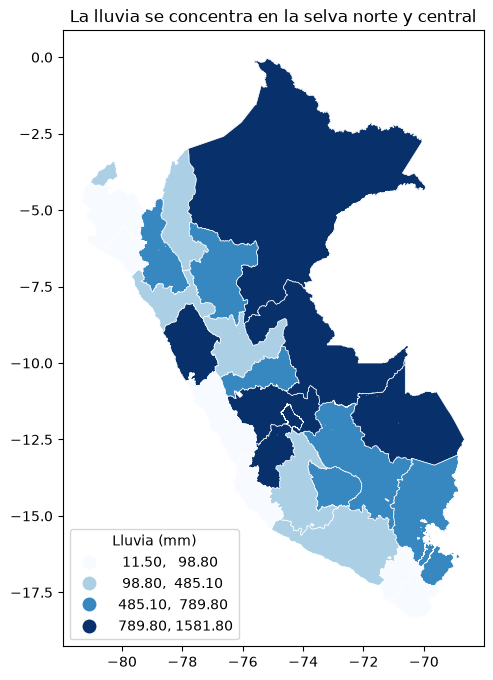

In [10]:
mapa_con_datos.plot(
    column="lluvia_total_mm",
    scheme="quantiles",
    k=4,
    cmap="Blues",
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    figsize=(6, 8),
    legend_kwds={"title": "Lluvia (mm)", "loc": "lower left"},
).set_title("La lluvia se concentra en la selva norte y central", fontsize=12);

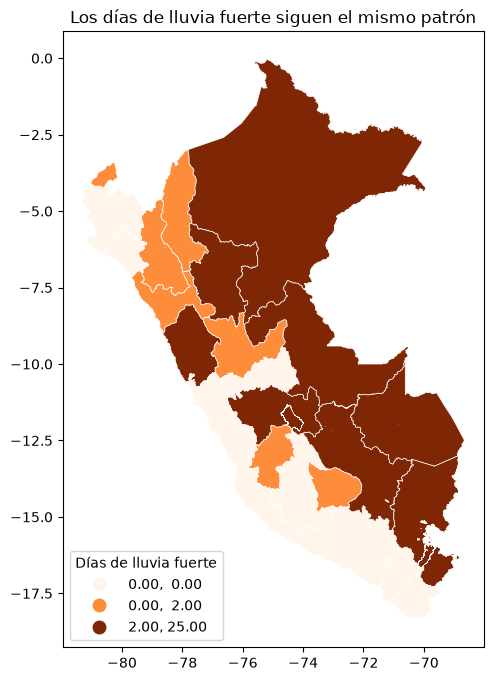

In [11]:
mapa_con_datos.plot(
    column="dias_lluvia_fuerte",
    scheme="quantiles",
    k=3,
    cmap="Oranges",
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    figsize=(6, 8),
    legend_kwds={"title": "Días de lluvia fuerte", "loc": "lower left"},
).set_title("Los días de lluvia fuerte siguen el mismo patrón", fontsize=12);

*Fuente: Open-Meteo (reanálisis) y PCM en gob.pe, enero-mayo 2022.*

## 7. Mapa interactivo con Folium

`folium.Choropleth` pinta el color. Una capa `GeoJson` encima agrega el
**tooltip**: el cuadro que aparece al pasar el cursor.

Este mapa no se guarda con output en el notebook (pesa varios MB): se
genera al correr la celda.

In [12]:
mapa_folium = folium.Map(location=[-9.2, -75.0], zoom_start=5, tiles="OpenStreetMap")

folium.Choropleth(
    geo_data=mapa_con_datos,
    data=mapa_con_datos,
    columns=["ubigeo", "lluvia_total_mm"],
    key_on="feature.properties.ubigeo",
    fill_color="Blues",
    fill_opacity=0.8,
    line_opacity=0.4,
    legend_name="Lluvia acumulada ene-may 2022 (mm)",
).add_to(mapa_folium)

In [13]:
folium.GeoJson(
    mapa_con_datos[["departamento", "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias", "geometry"]],
    style_function=lambda x: {"fillOpacity": 0, "weight": 0},
    tooltip=folium.GeoJsonTooltip(
        fields=["departamento", "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias"],
        aliases=["Departamento", "Lluvia (mm)", "Días de lluvia fuerte", "Declaratorias"],
    ),
).add_to(mapa_folium)

mapa_folium

## 8. ¿Qué patrón geográfico resalta?

**La lluvia sigue la geografía; las declaratorias no.**

- La lluvia se concentra en la **selva**: Loreto (1,581.8 mm), Ucayali
  (1,288.8 mm) y Madre de Dios (908.0 mm), más Áncash (975.3 mm) y Junín
  (910.4 mm) en la sierra.
- La **costa** casi no recibe lluvia: Tacna (11.5 mm), Moquegua (17.8 mm),
  Ica (25.1 mm).
- Las tres declaratorias están en **Amazonas, Ayacucho y Piura**: un
  departamento de sierra norte, uno de sierra sur y uno de costa norte,
  separados entre sí y sin ser los más lluviosos.

### ¿Qué muestra el mapa que no mostraban los gráficos?

Los gráficos de la Parte 1 decían que las declaratorias no coincidían con
la lluvia. El mapa agrega **dónde**: el exceso de lluvia está en la selva
y las emergencias, en departamentos dispersos. Una explicación posible es
que una emergencia depende del daño (viviendas, caminos, vulnerabilidad) y
no solo de los milímetros. Los datos que tenemos no permiten probarlo.

**Cautela:** la lluvia está medida en un solo punto, la capital de cada
departamento. Lima y Callao comparten el mismo valor (39.2 mm) porque caen
en la misma celda del modelo.

## Qué hicimos

| Paso | Qué hicimos | Código |
|---|---|---|
| 1 | Leer tabla y mapa | `pd.read_csv(..., dtype=str)`, `gpd.read_file(...)` |
| 2 | Ponerle ubigeo al mapa | `merge` con `ubigeos.csv` por nombre sin tildes |
| 3 | Ver qué pasa si el ubigeo es número | `pd.read_csv` sin `dtype` |
| 4 | Cruzar y contar los que no cruzan | `merge(..., how="left", indicator=True)` |
| 5 | Guardar mapa ligero para el dashboard | `simplify(0.01)`, `to_file` |
| 6 | Dos coropletas por cuantiles | `.plot(column=..., scheme="quantiles")` |
| 7 | Mapa interactivo con tooltip | `folium.Choropleth`, `folium.GeoJsonTooltip` |